# RetailPulse – Demand Forecasting

## Objective

Analyze historical product demand and forecast future demand
to support inventory planning.

## Business Questions

1. Which products have the highest demand?
2. How does product demand change over time?
3. Are there seasonal demand patterns?
4. Which products are suitable for forecasting?
5. What is the expected demand for the next 30 days?
6. How can demand forecasts support inventory decisions?

## Approach

Sales Transactions
        ↓
Daily Product Demand
        ↓
Demand Analysis
        ↓
Time-Series Preparation
        ↓
Forecasting Model
        ↓
30-Day Forecast
        ↓
Inventory Recommendation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Sales  Data

In [2]:
CLEANED_DIR = Path("../data/cleaned")

sales = pd.read_csv(
    CLEANED_DIR / "retail_sales.csv"
)

print("Sales dataset loaded.")
print("Shape:", sales.shape)

Sales dataset loaded.
Shape: (779425, 17)


In [3]:
sales["InvoiceDate"] = pd.to_datetime(
    sales["InvoiceDate"],
    errors="coerce"
)

print("InvoiceDate type:")
print(sales["InvoiceDate"].dtype)

InvoiceDate type:
datetime64[ns]


In [4]:
print("Missing dates:", sales["InvoiceDate"].isna().sum())
print("Missing products:", sales["StockCode"].isna().sum())
print("Missing quantities:", sales["Quantity"].isna().sum())

Missing dates: 0
Missing products: 0
Missing quantities: 0


In [5]:
print("Start date:", sales["InvoiceDate"].min())
print("End date:", sales["InvoiceDate"].max())

Start date: 2009-12-01 07:45:00
End date: 2011-12-09 12:50:00


## Daily Total Demand

In [6]:
daily_demand = (
    sales
    .set_index("InvoiceDate")
    .resample("D")["Quantity"]
    .sum()
    .reset_index()
)

daily_demand.head()

,InvoiceDate,Quantity
0,2009-12-01,24335
1,2009-12-02,29679
2,2009-12-03,48009
3,2009-12-04,19954
4,2009-12-05,5119


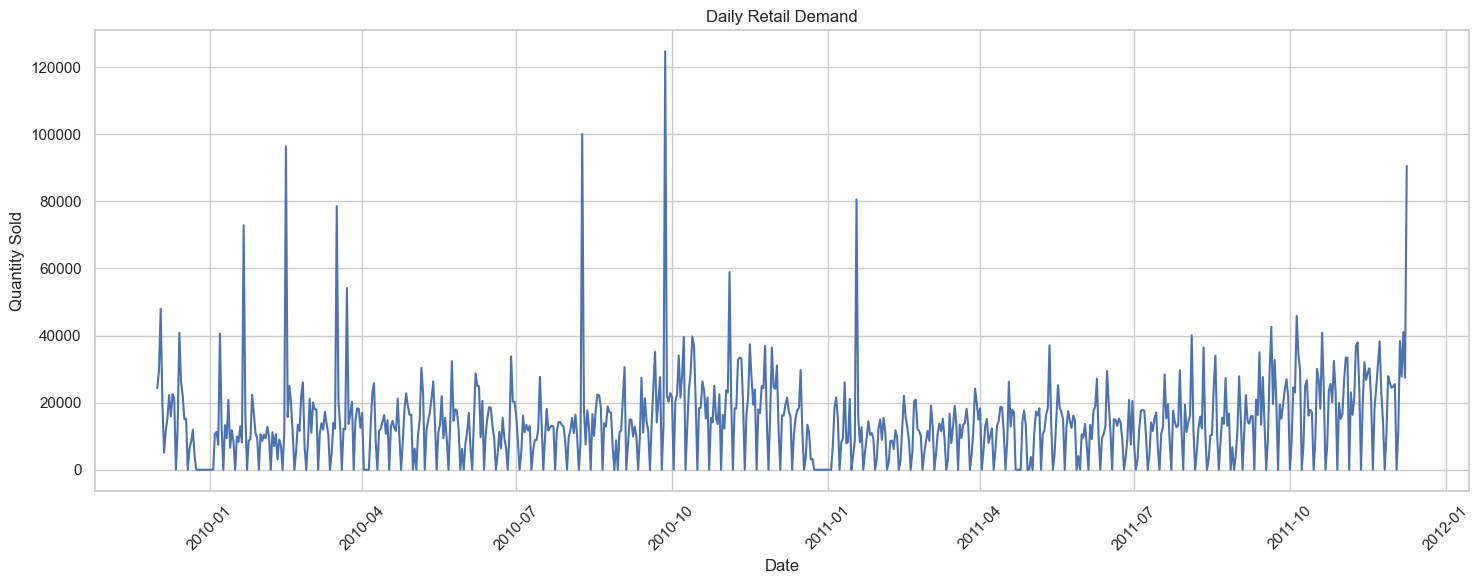

In [7]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=daily_demand,
    x="InvoiceDate",
    y="Quantity"
)

plt.title("Daily Retail Demand")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Monthly demand

In [8]:
monthly_demand = (
    sales
    .set_index("InvoiceDate")
    .resample("ME")["Quantity"]
    .sum()
    .reset_index()
)

monthly_demand

,InvoiceDate,Quantity
0,2009-12-31,398660
1,2010-01-31,370082
2,2010-02-28,371861
3,2010-03-31,502100
4,2010-04-30,350587
5,2010-05-31,384960
6,2010-06-30,389872
7,2010-07-31,324632
8,2010-08-31,452542
9,2010-09-30,567153


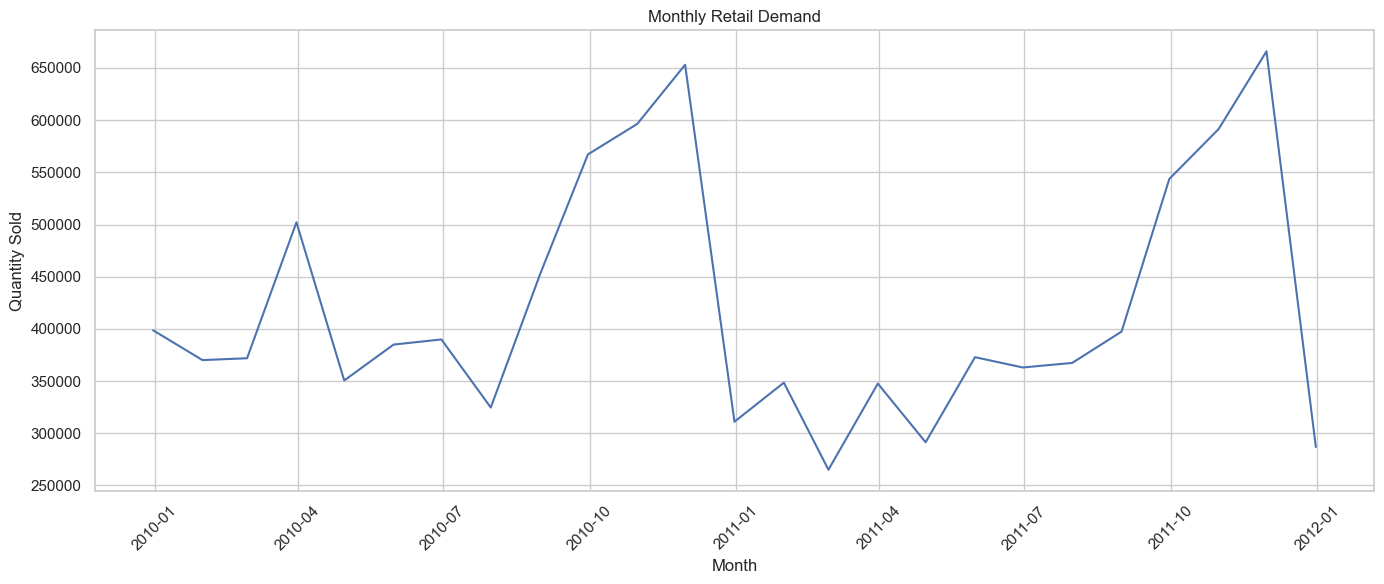

In [9]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_demand,
    x="InvoiceDate",
    y="Quantity"
)

plt.title("Monthly Retail Demand")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Identify top products by quantity

In [10]:
product_demand = (
    sales
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Quantity"]
    .sum()
    .reset_index()
    .sort_values(
        "Quantity",
        ascending=False
    )
)

product_demand.head(20)

,StockCode,Description,Quantity
4031,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,78234
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
4725,85099B,JUMBO BAG RED RETROSPOT,74224
115,17003,BROCADE RING PURSE,70082
1357,21977,PACK OF 60 PINK PAISLEY CAKE CASES,54592
4595,84991,60 TEATIME FAIRY CAKE CASES,52828
658,21212,PACK OF 72 RETRO SPOT CAKE CASES,45129


## Top 20 demand products

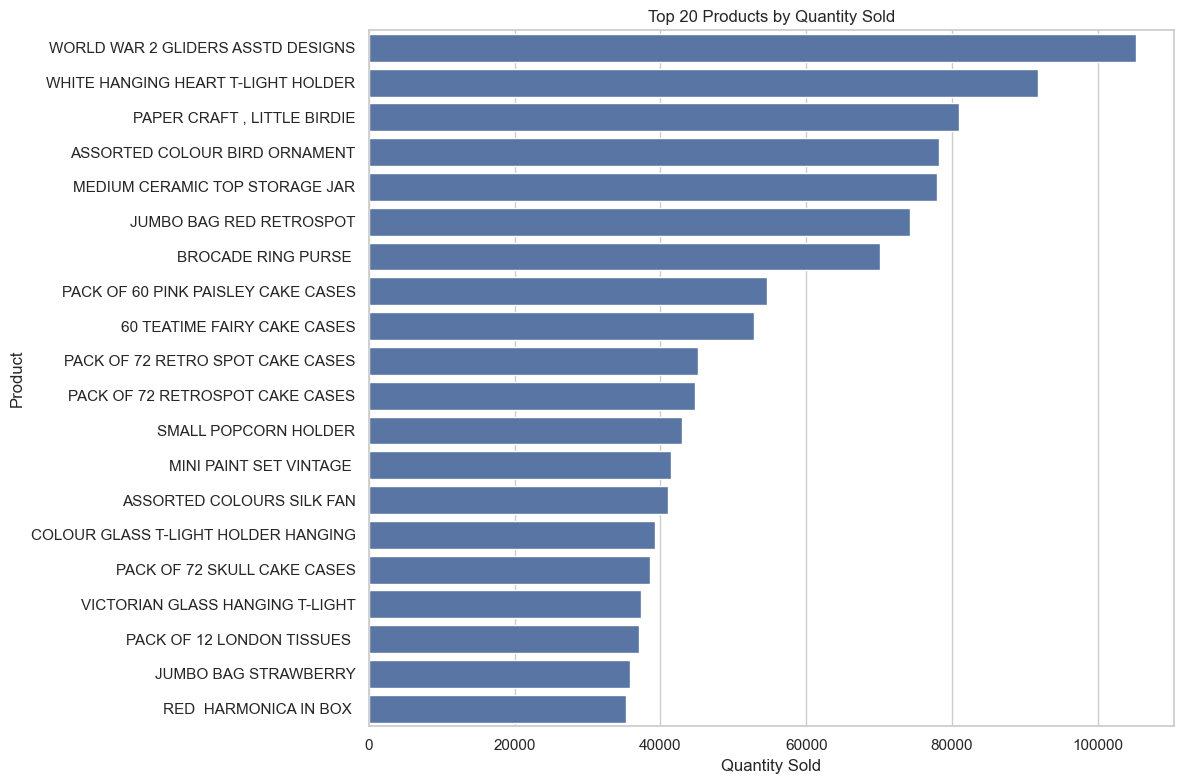

In [11]:
top_20_products = product_demand.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_20_products,
    x="Quantity",
    y="Description"
)

plt.title("Top 20 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## Product transaction coverage

In [13]:
product_coverage = (
    sales
    .groupby("StockCode")
    .agg(
        TransactionDays=(
            "InvoiceDate",
            lambda x: x.dt.date.nunique()
        ),
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum"),
        TransactionLines=("Invoice", "count")
    )
    .reset_index()
)

In [14]:
product_coverage.sort_values(
    "TotalQuantity",
    ascending=False
).head(20)

,StockCode,TransactionDays,TotalQuantity,TotalRevenue,TransactionLines
3410,84077,458,105185,24098.03,921
4058,85099B,581,93436,167920.64,3296
4080,85123A,603,91814,247203.36,5023
601,21212,581,89850,43390.03,2557
2726,23843,1,80995,168469.60,1
3819,84879,579,78234,124351.86,2692
2324,23166,115,77916,81416.73,198
1405,22197,538,76944,58267.74,1794
108,17003,269,70082,14640.96,393
1219,21977,541,54592,26407.35,1603


## Select a forecasting candidate

In [15]:
forecast_candidates = product_coverage[
    product_coverage["TransactionDays"] >= 30
].sort_values(
    "TotalQuantity",
    ascending=False
)

forecast_candidates.head(20)

,StockCode,TransactionDays,TotalQuantity,TotalRevenue,TransactionLines
3410,84077,458,105185,24098.03,921
4058,85099B,581,93436,167920.64,3296
4080,85123A,603,91814,247203.36,5023
601,21212,581,89850,43390.03,2557
3819,84879,579,78234,124351.86,2692
2324,23166,115,77916,81416.73,198
1405,22197,538,76944,58267.74,1794
108,17003,269,70082,14640.96,393
1219,21977,541,54592,26407.35,1603
3938,84991,534,52828,25785.92,1813


## Select the first product

In [16]:
FORECAST_PRODUCT = (
    forecast_candidates.iloc[0]["StockCode"]
)

print(
    "Selected product:",
    FORECAST_PRODUCT
)

Selected product: 84077


In [17]:
selected_product = sales[
    sales["StockCode"] == FORECAST_PRODUCT
]["Description"].dropna().mode()

print(
    "Description:",
    selected_product.iloc[0]
    if len(selected_product) > 0
    else "Unknown"
)

Description: WORLD WAR 2 GLIDERS ASSTD DESIGNS


## Create product time series

In [18]:
product_sales = sales[
    sales["StockCode"] == FORECAST_PRODUCT
].copy()

In [19]:
product_daily = (
    product_sales
    .set_index("InvoiceDate")
    .resample("D")["Quantity"]
    .sum()
    .reset_index()
)

## Fill missing dates

In [21]:
product_daily = (
    product_daily
    .set_index("InvoiceDate")
    .asfreq("D", fill_value=0)
    .reset_index()
)

In [22]:
product_daily.head(20)

,InvoiceDate,Quantity
0,2009-12-01,48
1,2009-12-02,435
2,2009-12-03,56
3,2009-12-04,144
4,2009-12-05,48
5,2009-12-06,0
6,2009-12-07,96
7,2009-12-08,576
8,2009-12-09,0
9,2009-12-10,384


## Plot product demand

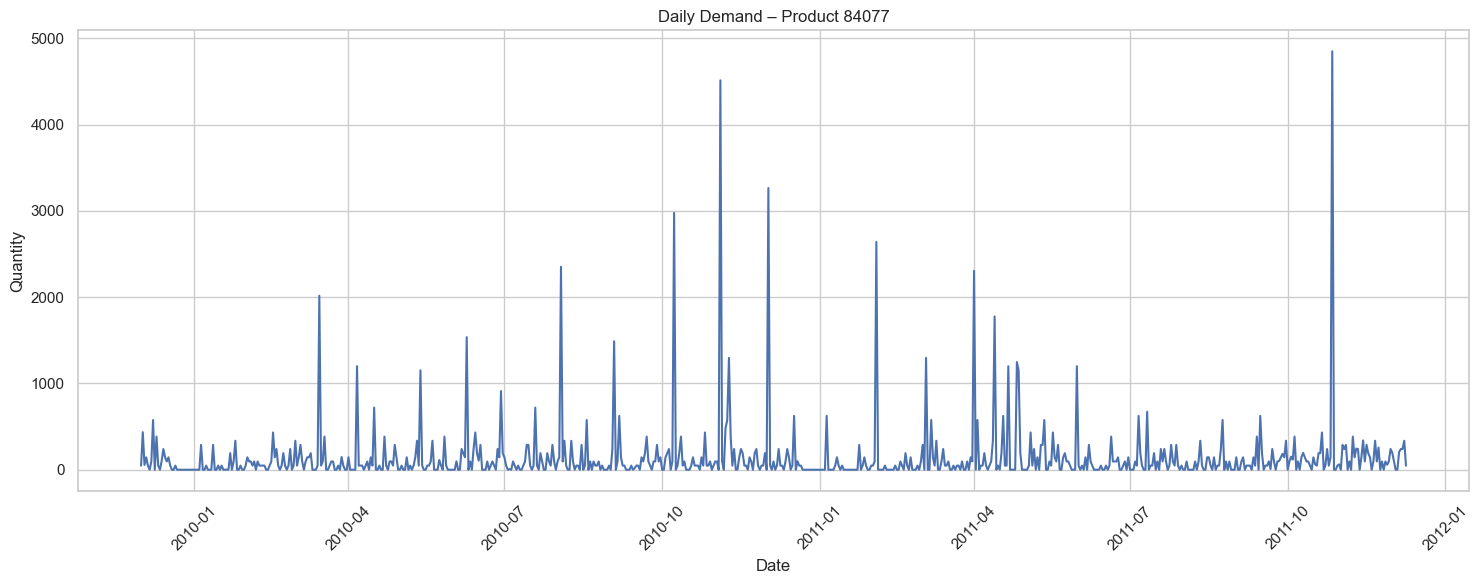

In [23]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=product_daily,
    x="InvoiceDate",
    y="Quantity"
)

plt.title(
    f"Daily Demand – Product {FORECAST_PRODUCT}"
)

plt.xlabel("Date")
plt.ylabel("Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Rolling average

In [24]:
product_daily["Rolling_7D"] = (
    product_daily["Quantity"]
    .rolling(7)
    .mean()
)

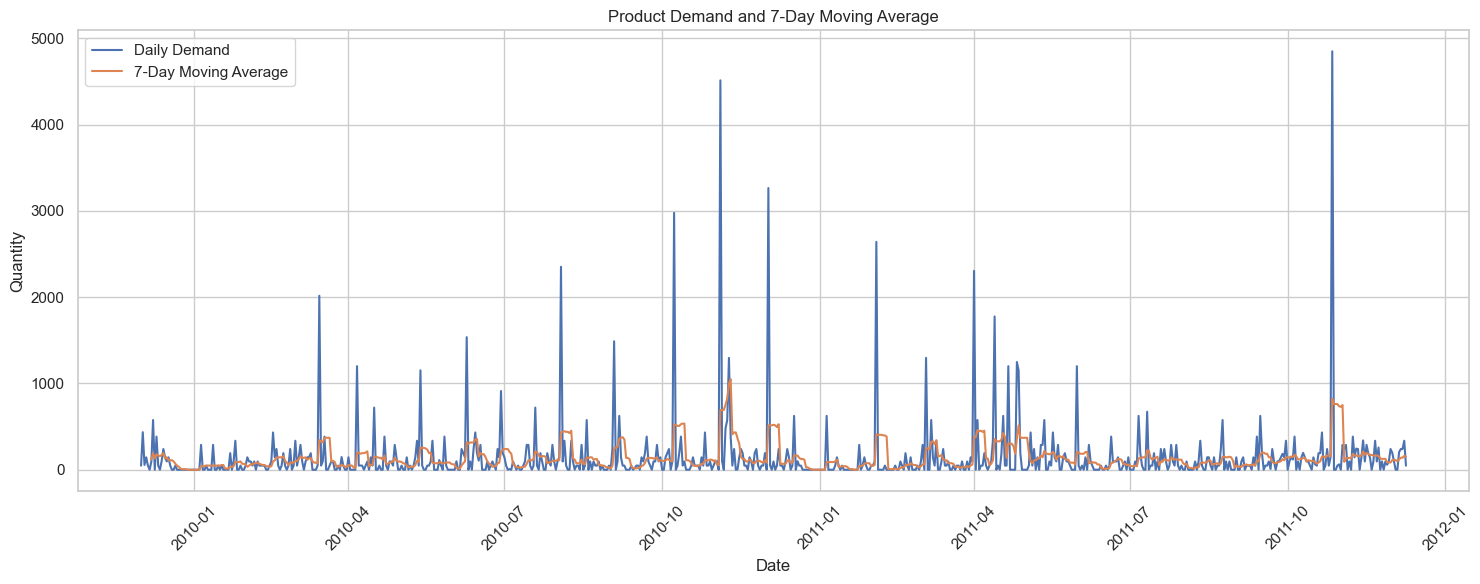

In [25]:
plt.figure(figsize=(15, 6))

plt.plot(
    product_daily["InvoiceDate"],
    product_daily["Quantity"],
    label="Daily Demand"
)

plt.plot(
    product_daily["InvoiceDate"],
    product_daily["Rolling_7D"],
    label="7-Day Moving Average"
)

plt.title("Product Demand and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Quantity")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Weekly demand

In [26]:
weekly_product_demand = (
    product_daily
    .set_index("InvoiceDate")["Quantity"]
    .resample("W")
    .sum()
    .reset_index()
)

weekly_product_demand.head()

,InvoiceDate,Quantity
0,2009-12-06,731
1,2009-12-13,1204
2,2009-12-20,672
3,2009-12-27,48
4,2010-01-03,0


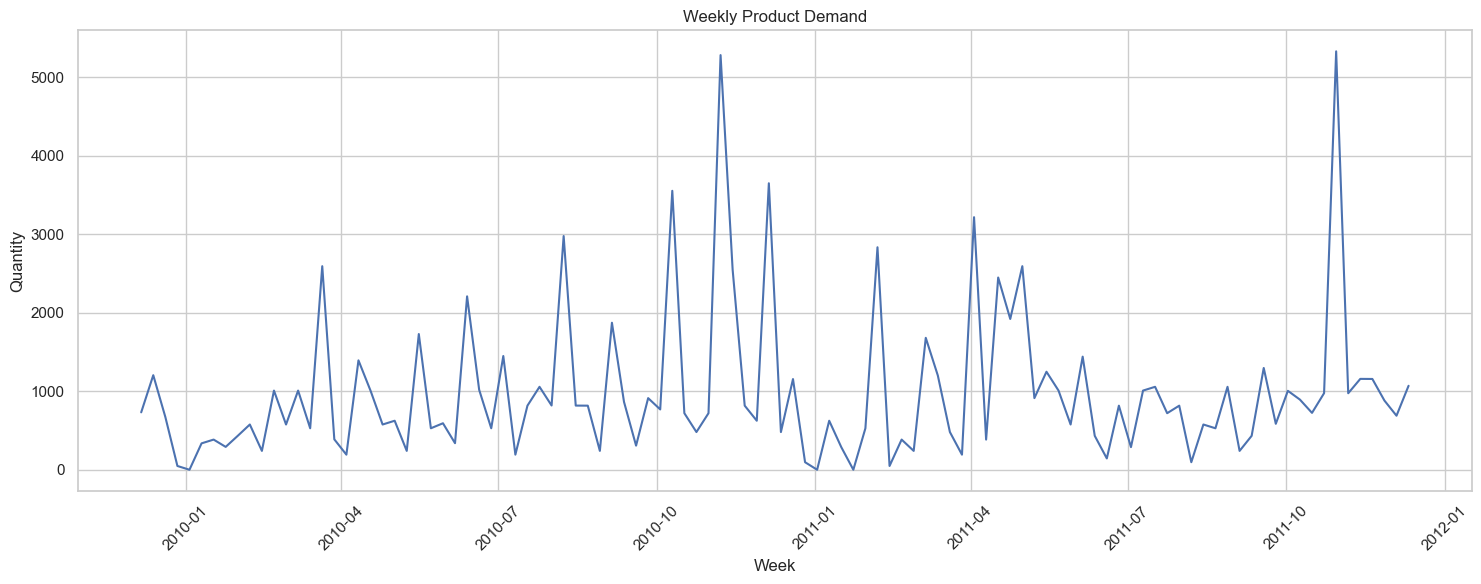

In [27]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=weekly_product_demand,
    x="InvoiceDate",
    y="Quantity"
)

plt.title("Weekly Product Demand")
plt.xlabel("Week")
plt.ylabel("Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Train/test split

In [28]:
TEST_DAYS = 30

train = product_daily.iloc[:-TEST_DAYS].copy()

test = product_daily.iloc[-TEST_DAYS:].copy()

print("Training period:", train.shape)
print("Testing period:", test.shape)

print(
    "Training end:",
    train["InvoiceDate"].max()
)

print(
    "Testing start:",
    test["InvoiceDate"].min()
)

Training period: (709, 3)
Testing period: (30, 3)
Training end: 2011-11-09 00:00:00
Testing start: 2011-11-10 00:00:00


## Baseline model: Naive forecast

In [29]:
baseline_value = (
    train["Quantity"]
    .tail(7)
    .mean()
)

print(
    "Baseline forecast:",
    round(baseline_value, 2)
)

Baseline forecast: 164.57


In [30]:
test["BaselineForecast"] = baseline_value

## Evaluate baseline

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    test["Quantity"],
    test["BaselineForecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["Quantity"],
        test["BaselineForecast"]
    )
)

print("Baseline MAE :", round(mae, 2))
print("Baseline RMSE:", round(rmse, 2))

Baseline MAE : 98.31
Baseline RMSE: 110.64


## Actual vs baseline

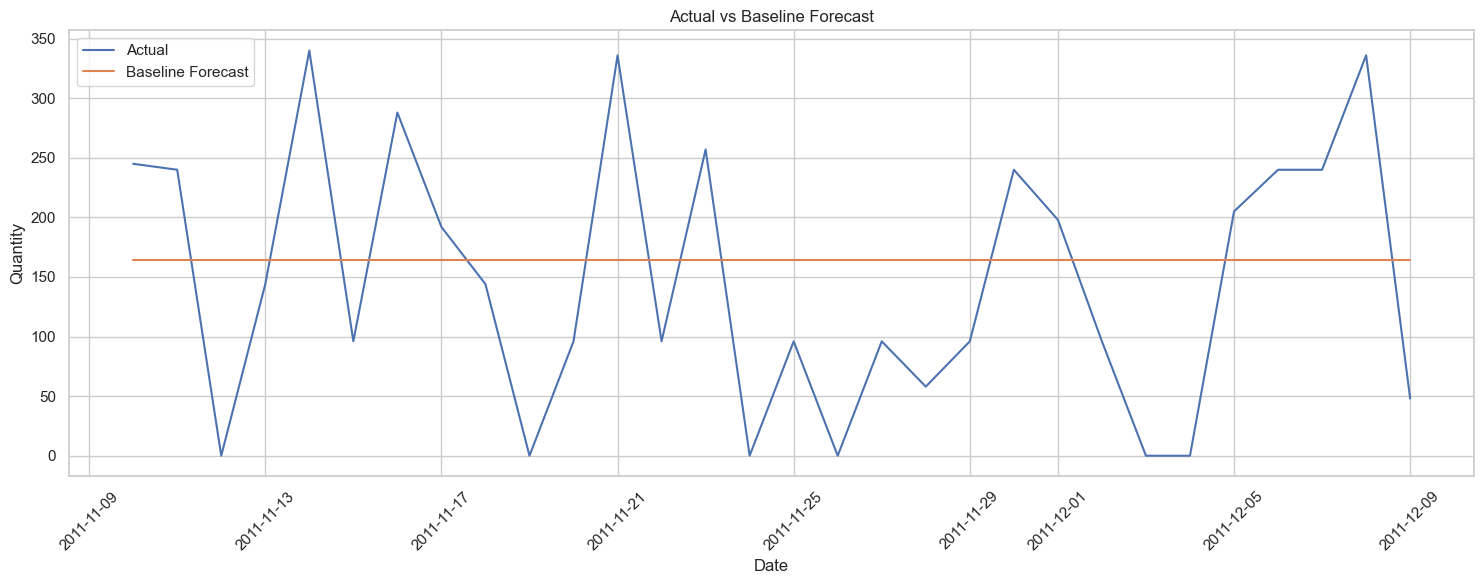

In [32]:
plt.figure(figsize=(15, 6))

plt.plot(
    test["InvoiceDate"],
    test["Quantity"],
    label="Actual"
)

plt.plot(
    test["InvoiceDate"],
    test["BaselineForecast"],
    label="Baseline Forecast"
)

plt.title("Actual vs Baseline Forecast")
plt.xlabel("Date")
plt.ylabel("Quantity")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Install Prophet

In [33]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 2.1 MB/s eta 0:00:06
   - -------------------------------------- 0.5/12.1 MB 2.1 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/12.1 MB 1.2 MB/s eta 0:00:10
   ---- ----------------------------------- 1.3/12.1 MB 1.4 MB/s eta 0:00:08
   ------- -------------------------------- 2.4/12.1 MB 2.1 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/12.1 MB 2.4 MB/s eta 0:00:04
   -------------- ------------------------- 4.5/12.1 MB 2.9 MB/s eta 0:00:03
   ---------------- ----------------------- 5.0/12.1 MB 3.1 MB/s eta 0:00:03
   ---------------- ----------------------- 5.0/12.1 MB 3.1 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/12.1 MB 2.6 MB/s eta 0:00:03
   -------------------- ------------------- 6.3/12.1 MB 2.7 MB/s eta 0:00:03
   --------------------- ------------------ 6.6/12.1 MB 2.6 MB/s eta 0:00:03
   ---

In [34]:
from prophet import Prophet

print("Prophet imported successfully.")

Importing plotly failed. Interactive plots will not work.


Prophet imported successfully.


## Prepare Prophet data

In [35]:
prophet_train = train[
    ["InvoiceDate", "Quantity"]
].rename(
    columns={
        "InvoiceDate": "ds",
        "Quantity": "y"
    }
)

In [36]:
prophet_train.head()

,ds,y
0,2009-12-01,48
1,2009-12-02,435
2,2009-12-03,56
3,2009-12-04,144
4,2009-12-05,48


## Train Prophet

In [37]:
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(
    prophet_train
)

12:41:53 - cmdstanpy - INFO - Chain [1] start processing
12:41:54 - cmdstanpy - INFO - Chain [1] done processing


## Create future dates

In [38]:
future = prophet_model.make_future_dataframe(
    periods=30,
    freq="D"
)

future.tail()

,ds
734,2011-12-05
735,2011-12-06
736,2011-12-07
737,2011-12-08
738,2011-12-09


## Forecast

In [39]:
forecast = prophet_model.predict(
    future
)

In [40]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(30)

,ds,yhat,yhat_lower,yhat_upper
709,2011-11-10,478.200560,-41.428225,979.993823
710,2011-11-11,336.175734,-130.869307,814.972084
711,2011-11-12,172.483840,-299.724836,653.852615
712,2011-11-13,230.113143,-273.743384,685.714171
713,2011-11-14,292.675554,-161.143692,766.103792
714,2011-11-15,325.110044,-117.989716,819.911094
715,2011-11-16,279.157415,-195.118657,773.597384
716,2011-11-17,402.614705,-54.906903,923.911937
717,2011-11-18,258.531104,-238.742735,764.813313
718,2011-11-19,94.034207,-416.560235,569.179505


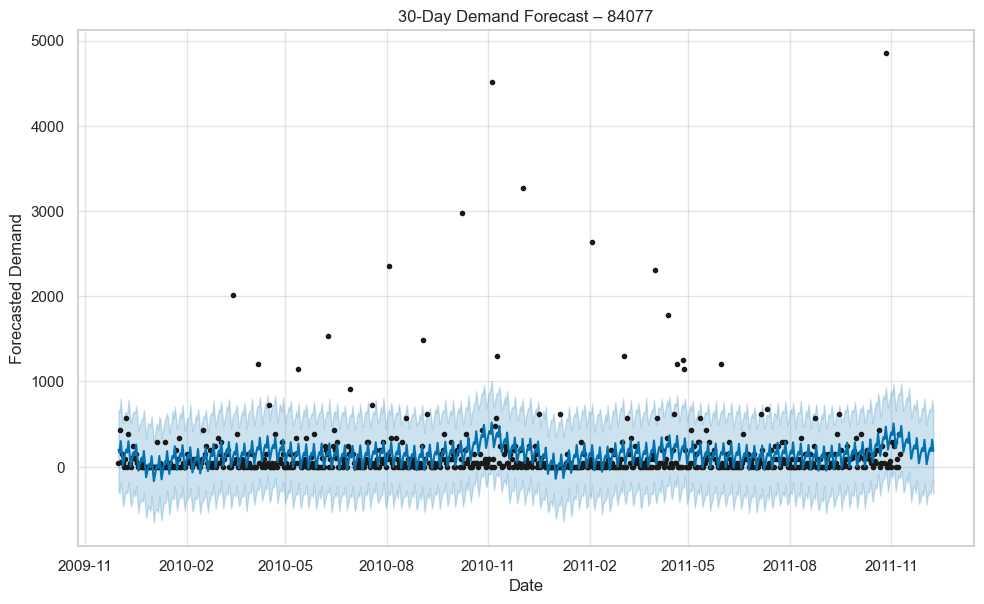

In [41]:
fig = prophet_model.plot(
    forecast
)

plt.title(
    f"30-Day Demand Forecast – {FORECAST_PRODUCT}"
)

plt.xlabel("Date")
plt.ylabel("Forecasted Demand")

plt.show()

## Forecast components

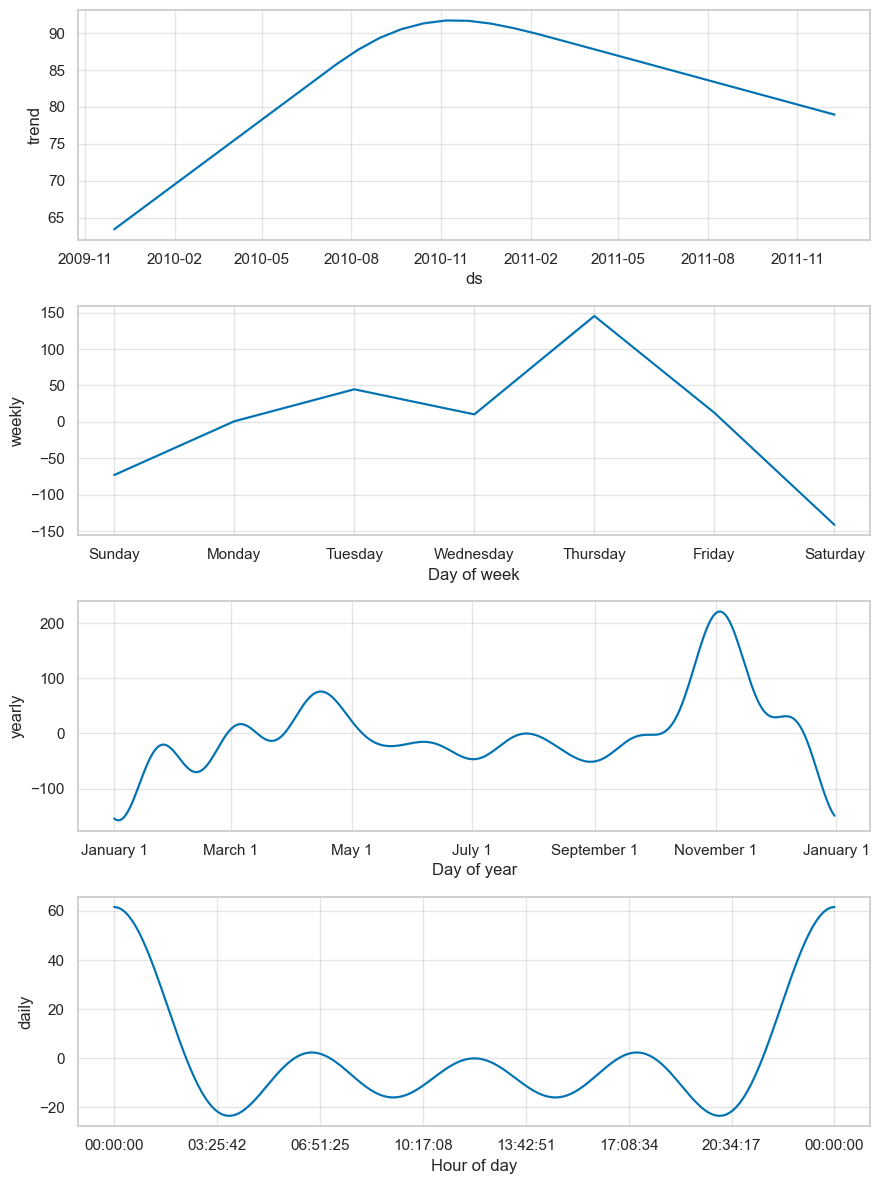

In [42]:
fig = prophet_model.plot_components(
    forecast
)

plt.show()

## Extract 30-day forecast

In [43]:
future_forecast = (
    forecast[
        forecast["ds"] > train["InvoiceDate"].max()
    ][
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ]
    .head(30)
    .copy()
)

future_forecast

,ds,yhat,yhat_lower,yhat_upper
709,2011-11-10,478.200560,-41.428225,979.993823
710,2011-11-11,336.175734,-130.869307,814.972084
711,2011-11-12,172.483840,-299.724836,653.852615
712,2011-11-13,230.113143,-273.743384,685.714171
713,2011-11-14,292.675554,-161.143692,766.103792
714,2011-11-15,325.110044,-117.989716,819.911094
715,2011-11-16,279.157415,-195.118657,773.597384
716,2011-11-17,402.614705,-54.906903,923.911937
717,2011-11-18,258.531104,-238.742735,764.813313
718,2011-11-19,94.034207,-416.560235,569.179505


## Prevent negative forecasts

In [44]:
future_forecast["ForecastDemand"] = (
    future_forecast["yhat"]
    .clip(lower=0)
)

## Forecast summary

In [45]:
forecast_summary = pd.DataFrame({
    "Metric": [
        "Average Daily Forecast",
        "Total 30-Day Forecast",
        "Minimum Daily Forecast",
        "Maximum Daily Forecast"
    ],
    
    "Value": [
        future_forecast["ForecastDemand"].mean(),
        future_forecast["ForecastDemand"].sum(),
        future_forecast["ForecastDemand"].min(),
        future_forecast["ForecastDemand"].max()
    ]
})

forecast_summary.round(2)

,Metric,Value
0,Average Daily Forecast,221.69
1,Total 30-Day Forecast,6650.58
2,Minimum Daily Forecast,29.37
3,Maximum Daily Forecast,478.20


## Business Interpretation

# Demand Forecasting – Business Interpretation

The forecasting model estimates future product demand using historical
daily sales patterns.

The forecast can be used to:

1. Identify expected high-demand periods.
2. Estimate near-term product requirements.
3. Support inventory planning.
4. Reduce the risk of stockouts.
5. Reduce unnecessary overstocking.
6. Prioritize products for inventory monitoring.

The 30-day forecast represents an analytical prediction based on historical
transaction behavior and should be combined with actual inventory levels,
supplier lead times, promotions, and other operational information before
making purchasing decisions.

# Inventory recommendation

In [46]:
ASSUMED_LEAD_TIME_DAYS = 7
SAFETY_STOCK_DAYS = 3

In [47]:
average_daily_forecast = (
    future_forecast["ForecastDemand"].mean()
)

reorder_point = (
    average_daily_forecast
    * (
        ASSUMED_LEAD_TIME_DAYS
        + SAFETY_STOCK_DAYS
    )
)

print(
    "Average daily forecast:",
    round(average_daily_forecast, 2)
)

print(
    "Recommended reorder point:",
    round(reorder_point, 2)
)

Average daily forecast: 221.69
Recommended reorder point: 2216.86


## Save forecasting outputs

In [48]:
FORECAST_DIR = Path("../data/forecast")

FORECAST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [49]:
future_forecast.to_csv(
    FORECAST_DIR / "30_day_demand_forecast.csv",
    index=False
)

In [50]:
product_daily.to_csv(
    FORECAST_DIR / "selected_product_daily_demand.csv",
    index=False
)

In [51]:
forecast_summary.to_csv(
    FORECAST_DIR / "forecast_summary.csv",
    index=False
)